In [ ]:
import os
from google.colab import drive

# 1. Drive connect karo (Agar already mounted hai toh turant ho jayega)
drive.mount('/content/drive')

# 2. Extract the data directly to Colab's fast storage
print("📦 Extracting from Drive to Colab (Isme 2-3 minute lagenge)...")

# Path correct kar diya hai (c ki jagah MyDrive)
!unzip -q "/content/drive/MyDrive/SafeStreet_Data.zip" -d "/content/SafeStreet_Dataset"

print("✅ Extraction Complete! Folder structure:")
!ls -l /content/SafeStreet_Dataset

Mounted at /content/drive
📦 Extracting from Drive to Colab (Isme 2-3 minute lagenge)...
✅ Extraction Complete! Folder structure:
total 4
drwxr-xr-x 4 root root 4096 Mar 20 11:53 SafeStreet_Data


📸 Total frames found in Fighting class: 24684
🎬 Creating sequence from: Fighting002_x264_1430.png
✅ Success! Sequence Shape: (16, 224, 224, 3)


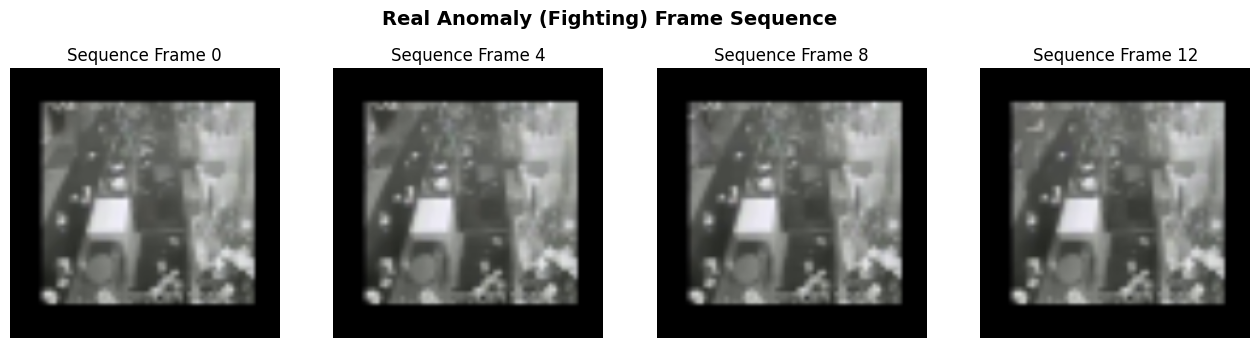

In [ ]:
import os, glob, cv2
import numpy as np
import matplotlib.pyplot as plt

TRAIN_DIR = '/content/SafeStreet_Dataset/SafeStreet_Data/Train'
NUM_FRAMES = 16
IMAGE_SIZE = 224

# 1. Fighting folder ke andar ki saari images (.png ya .jpg) uthao aur sort karo
images_path = os.path.join(TRAIN_DIR, 'Fighting', '*.*')
all_frames = sorted([f for f in glob.glob(images_path) if f.endswith(('.png', '.jpg'))])

if len(all_frames) >= NUM_FRAMES:
    print(f"📸 Total frames found in Fighting class: {len(all_frames)}")

    # 2. Pehli 16 consecutive images uthao (Yeh humara ek 'Video Clip' ban jayega)
    sequence_paths = all_frames[50:50+NUM_FRAMES] # Beech se 16 frames utha rahe hain better action ke liye

    print(f"🎬 Creating sequence from: {os.path.basename(sequence_paths[0])}")

    frames = []
    for img_path in sequence_paths:
        frame = cv2.imread(img_path)
        frame = cv2.resize(frame, (IMAGE_SIZE, IMAGE_SIZE))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    # 3. List of images ko numpy array (Tensor) mein convert karo
    frames_array = np.stack(frames)

    print(f"✅ Success! Sequence Shape: {frames_array.shape}")

    # 4. Display the sequence
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i, ax in enumerate(axes):
        f_idx = i * 4 # Showing frame 0, 4, 8, 12 from our 16-frame chunk
        ax.imshow(frames_array[f_idx])
        ax.set_title(f"Sequence Frame {f_idx}")
        ax.axis('off')
    plt.suptitle("Real Anomaly (Fighting) Frame Sequence", fontsize=14, fontweight='bold')
    plt.show()

else:
    print("❌ Not enough frames found. Please check the dataset path.")

In [ ]:
# ================================================================
# CELL 3 — BALANCED DATA PREPROCESSING & DATALOADER
# ================================================================
import os, glob, cv2, random
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

TRAIN_DIR = '/content/SafeStreet_Dataset/SafeStreet_Data/Train'
TEST_DIR = '/content/SafeStreet_Dataset/SafeStreet_Data/Test'
NUM_FRAMES = 16
IMAGE_SIZE = 224
BATCH_SIZE = 8

class SafeStreetDataset(Dataset):
    # Humne max_normal_clips=2500 add kiya hai balance karne ke liye
    def __init__(self, root_dir, num_frames=16, transform=None, max_normal_clips=2500):
        self.root_dir = root_dir
        self.num_frames = num_frames
        self.transform = transform
        self.clips = []
        self.labels = []

        self.classes = {'Fighting': 1, 'Assault': 1, 'NormalVideos': 0}
        print(f"🔍 Scanning directory: {root_dir}")

        for cls_name, label in self.classes.items():
            cls_path = os.path.join(root_dir, cls_name)
            if not os.path.exists(cls_path):
                continue

            all_imgs = sorted(glob.glob(os.path.join(cls_path, '*.*')))

            video_groups = {}
            for img in all_imgs:
                base_name = os.path.basename(img).rsplit('_', 1)[0]
                if base_name not in video_groups:
                    video_groups[base_name] = []
                video_groups[base_name].append(img)

            temp_clips = []
            for vid_name, frames in video_groups.items():
                frames = sorted(frames)
                for i in range(0, len(frames) - num_frames + 1, num_frames):
                    temp_clips.append(frames[i : i + num_frames])

            # ⚖️ THE BALANCING MAGIC ⚖️
            if cls_name == 'NormalVideos' and len(temp_clips) > max_normal_clips:
                print(f"  ⚠️ Balancing {cls_name}: Reducing from {len(temp_clips)} down to {max_normal_clips} clips!")
                random.seed(42)
                temp_clips = random.sample(temp_clips, max_normal_clips)

            for clip in temp_clips:
                self.clips.append(clip)
                self.labels.append(label)

            print(f"  📂 {cls_name}: Final Clips Ready -> {len(temp_clips)}")

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        clip_paths = self.clips[idx]
        label = self.labels[idx]
        frames = []
        for p in clip_paths:
            img = cv2.imread(p)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.transform:
                img = self.transform(img)
            frames.append(img)
        return torch.stack(frames), torch.tensor(label, dtype=torch.float32)

video_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("\n⚙️ Building Train Dataset...")
train_dataset = SafeStreetDataset(TRAIN_DIR, num_frames=NUM_FRAMES, transform=video_transforms, max_normal_clips=2500)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print("\n⚙️ Building Test Dataset...") # Test data mein max_normal_clips kam rakhenge
test_dataset = SafeStreetDataset(TEST_DIR, num_frames=NUM_FRAMES, transform=video_transforms, max_normal_clips=300)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\n🚀 Balanced DataLoader Ready!")
print(f"Total Training Clips: {len(train_dataset)} (Fast & Efficient!)")


⚙️ Building Train Dataset...
🔍 Scanning directory: /content/SafeStreet_Dataset/SafeStreet_Data/Train
  📂 Fighting: Final Clips Ready -> 1524
  📂 Assault: Final Clips Ready -> 623
  ⚠️ Balancing NormalVideos: Reducing from 58876 down to 2500 clips!
  📂 NormalVideos: Final Clips Ready -> 2500

⚙️ Building Test Dataset...
🔍 Scanning directory: /content/SafeStreet_Dataset/SafeStreet_Data/Test
  📂 Fighting: Final Clips Ready -> 74
  📂 Assault: Final Clips Ready -> 165
  ⚠️ Balancing NormalVideos: Reducing from 3984 down to 300 clips!
  📂 NormalVideos: Final Clips Ready -> 300

🚀 Balanced DataLoader Ready!
Total Training Clips: 4647 (Fast & Efficient!)


In [ ]:
# ================================================================
# CELL 4 — LOADING THE AI BRAIN (VideoMAE) & OPTIMIZER
# ================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import VideoMAEForVideoClassification

# ── 1. Device Setup (Checking for GPU) ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Hardware Engine: {device.type.upper()}")
if device.type == 'cuda':
    print(f"🎮 GPU Name: {torch.cuda.get_device_name(0)}")

# ── 2. Load Pre-trained VideoMAE Model ──
print("\n🧠 Downloading & Loading VideoMAE Base Model from HuggingFace...")
# Hum 'videomae-base' use kar rahe hain taaki baad mein Jetson Nano par easily chal sake
model = VideoMAEForVideoClassification.from_pretrained(
    "MCG-NJU/videomae-base",
    num_labels=2, # Humari 2 classes hain: Normal (0) aur Anomaly (1)
    ignore_mismatched_sizes=True # Ignore purana 400-class wala head
)

# Model ko GPU par bhej do
model = model.to(device)
print("✅ Model successfully loaded and moved to GPU!")

# ── 3. Define Optimizer & Loss Function ──
# AdamW Transformer models ke liye sabse best optimizer mana jata hai
learning_rate = 5e-5
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# CrossEntropyLoss classification ke liye use hota hai
criterion = nn.CrossEntropyLoss()

# ── 4. Parameter Count Check ──
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"📊 Total Trainable Parameters: {total_params:,}")

print("\n🚀 Ready for the Final Step: The Training Loop!")

🔥 Hardware Engine: CUDA
🎮 GPU Name: Tesla T4

🧠 Downloading & Loading VideoMAE Base Model from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/377M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/184 [00:00<?, ?it/s]

VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base
Key                                                                  | Status     | 
---------------------------------------------------------------------+------------+-
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_after.bias             | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.output.dense.bias      | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.key.weight   | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.weight              | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.v_bias       | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.intermediate.dense.weight        | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.layernorm_before.bias            | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.attention.attention.q_bias       | UNEXPECTED | 
decoder.decoder_layers.{0, 1, 2, 3}.output.dense.bias                | UNEXPECT

✅ Model successfully loaded and moved to GPU!
📊 Total Trainable Parameters: 86,228,738

🚀 Ready for the Final Step: The Training Loop!


In [ ]:
# ================================================================
# CELL 5 — THE TRAINING ENGINE
# ================================================================
import time

EPOCHS = 3
print_every = 50 # Har 50 batches ke baad status print karega

print(f"🚀 Starting VideoMAE Training for {EPOCHS} Epochs...\n")
start_time = time.time()

for epoch in range(EPOCHS):
    model.train() # Model ko Training Mode mein daalo
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    print(f"{"="*40}")
    print(f"🔄 EPOCH {epoch+1}/{EPOCHS} STARTED")
    print(f"{"="*40}")

    for batch_idx, (videos, labels) in enumerate(train_loader):
        # 1. Data ko GPU par bhejo
        videos = videos.to(device)
        labels = labels.to(device).long() # Labels should be LongTensor for CrossEntropy

        # 2. Forward Pass: Model predictions nikalta hai
        outputs = model(videos)
        logits = outputs.logits # Prediction probabilities

        # 3. Loss Calculation: Galti kitni hui?
        loss = criterion(logits, labels)

        # 4. Backward Pass & Optimization: Galti theek karo
        optimizer.zero_grad() # Purane gradients clear karo
        loss.backward()       # Naye gradients calculate karo
        optimizer.step()      # Weights update karo

        # --- Metrics tracking ---
        running_loss += loss.item() * videos.size(0)
        _, predicted = torch.max(logits, 1) # Sabse high probability wali class
        correct_preds += (predicted == labels).sum().item()
        total_samples += labels.size(0)

        # Har 50 batches ke baad LIVE update
        if (batch_idx + 1) % print_every == 0:
            current_loss = running_loss / total_samples
            current_acc = (correct_preds / total_samples) * 100
            print(f"  ⏳ Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {current_loss:.4f} | Acc: {current_acc:.2f}%")

    # --- End of Epoch Summary ---
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = (correct_preds / len(train_dataset)) * 100

    print(f"\n✅ EPOCH {epoch+1} FINISHED!")
    print(f"📈 Train Loss: {epoch_loss:.4f} | Train Accuracy: {epoch_acc:.2f}%\n")

total_time = (time.time() - start_time) / 60
print(f"🎉 TRAINING COMPLETE in {total_time:.2f} minutes!")

# ── Save the Model (Bohot Zaroori!) ──
torch.save(model.state_dict(), '/content/SafeStreet_VideoMAE.pth')
print("💾 Model saved as 'SafeStreet_VideoMAE.pth'")

🚀 Starting VideoMAE Training for 3 Epochs...

🔄 EPOCH 1/3 STARTED
  ⏳ Epoch 1 | Batch 50/581 | Loss: 0.4936 | Acc: 77.25%
  ⏳ Epoch 1 | Batch 100/581 | Loss: 0.4025 | Acc: 82.62%
  ⏳ Epoch 1 | Batch 150/581 | Loss: 0.3610 | Acc: 85.42%
  ⏳ Epoch 1 | Batch 200/581 | Loss: 0.2996 | Acc: 87.81%
  ⏳ Epoch 1 | Batch 250/581 | Loss: 0.2743 | Acc: 89.25%
  ⏳ Epoch 1 | Batch 300/581 | Loss: 0.2478 | Acc: 90.33%
  ⏳ Epoch 1 | Batch 350/581 | Loss: 0.2432 | Acc: 90.46%
  ⏳ Epoch 1 | Batch 400/581 | Loss: 0.2289 | Acc: 91.09%
  ⏳ Epoch 1 | Batch 450/581 | Loss: 0.2154 | Acc: 91.75%
  ⏳ Epoch 1 | Batch 500/581 | Loss: 0.2002 | Acc: 92.38%
  ⏳ Epoch 1 | Batch 550/581 | Loss: 0.1881 | Acc: 92.84%

✅ EPOCH 1 FINISHED!
📈 Train Loss: 0.1806 | Train Accuracy: 93.14%

🔄 EPOCH 2/3 STARTED
  ⏳ Epoch 2 | Batch 50/581 | Loss: 0.1040 | Acc: 96.50%
  ⏳ Epoch 2 | Batch 100/581 | Loss: 0.0874 | Acc: 97.00%
  ⏳ Epoch 2 | Batch 150/581 | Loss: 0.0799 | Acc: 97.25%
  ⏳ Epoch 2 | Batch 200/581 | Loss: 0.0684 | Acc: 

🕵️‍♀️ Starting Evaluation on Unseen Test Data...
Please wait, analyzing test videos...

🎯 FINAL TEST ACCURACY: 79.41%

📊 Detailed Classification Report:
                   precision    recall  f1-score   support

       Normal (0)       0.74      0.96      0.84       300
Anomaly/Crime (1)       0.93      0.58      0.71       239

         accuracy                           0.79       539
        macro avg       0.83      0.77      0.78       539
     weighted avg       0.82      0.79      0.78       539



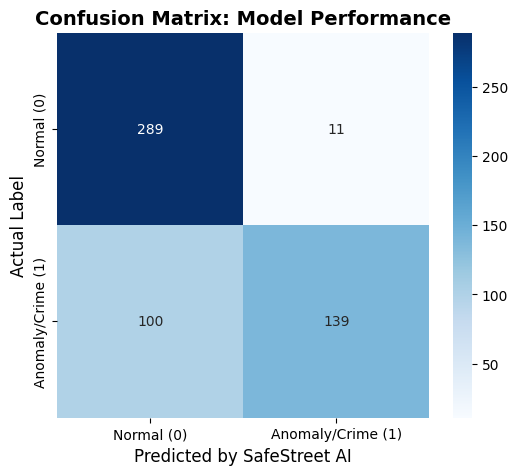

In [ ]:
# ================================================================
# CELL 6 — EVALUATION ON UNSEEN TEST DATA
# ================================================================
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("🕵️‍♀️ Starting Evaluation on Unseen Test Data...")
print("Please wait, analyzing test videos...\n")

# 1. Model ko 'Evaluation' mode mein daalo (Taki naye patterns memorize na kare)
model.eval()

correct = 0
total = 0
all_preds = []
all_labels = []

# 2. No_grad() saves memory and makes testing 2x faster
with torch.no_grad():
    for batch_idx, (videos, labels) in enumerate(test_loader):
        videos = videos.to(device)
        labels = labels.to(device).long()

        # Model predictions
        outputs = model(videos)
        logits = outputs.logits
        _, predicted = torch.max(logits, 1)

        # Track accuracy
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Store for detailed report
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Final Overall Accuracy
test_acc = (correct / total) * 100
print(f"{"="*40}")
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.2f}%")
print(f"{"="*40}\n")

# 4. Detailed Classification Report (For GitHub/Resume)
target_names = ['Normal (0)', 'Anomaly/Crime (1)']
print("📊 Detailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=target_names))

# 5. Visualizing the Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted by SafeStreet AI', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title('Confusion Matrix: Model Performance', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
import shutil

# Model ko Colab se uthakar direct Google Drive mein copy kar rahe hain
source = '/content/SafeStreet_VideoMAE.pth'
destination = '/content/drive/MyDrive/SafeStreet_VideoMAE.pth'

shutil.copy(source, destination)
print("✅ Model successfully safely copied to your Google Drive!")

✅ Model successfully safely copied to your Google Drive!
